<a href="https://colab.research.google.com/github/HeydrianAntunez/Public-Sources-Analysis-applied-AED-Statistic-Analysis-and-Machine-Learning/blob/main/Proyecto_Final_M%C3%B3dulo_3_Introducci%C3%B3n_al_An%C3%A1lisis_Exploratorio_de_Datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROYECTO: INTRODUCCIÓN AL ANÁLISIS EXPLORATORIO DE DATOS**

Una vez visto el ***Módulo 3: Análisis Exploratorio***, se presenta la siguiente actividad para que el alumnado pueda poner a prueba lo aprendido durante este módulo.

Dentro de la siguiente dinámica, realizar el siguiente **análisis exploratorio con aprendizaje estadístico** de cualquier dataset proveniente de la librería de ***Seaborn*** que no haya sido utilizado.

Se sugiere los siguientes puntos para llevar a cabo lo anterior:

*   Realizar un **análisis descriptivo** para comprender comportamiento de la descripción de los datos a través de resúmenes.
*   Realizar un **aprendizaje estadístico** para predecir comportamientos lineales de datos a través de la regresión lineal simple.

# **Proyecto: Gasto del hogar mexicano**

---


El siguiente proyecto tiene como objetivo analizar el gasto de las familias mexicanas. Se busca explorar cuáles son los principales productos adquiridos, los métodos de pagos utilizados, la cantidad de artículos adquiridos y el perfil del comprador.

🎯 **Objetivos del proyecto:**
* **Recopilar datos 📖:** fuente/origen, contexto y estructura.
* **Sanamiento de datos🧹:** diagnóstico del estado del dataset, identificación de valores nulos, normalización de datos categóricos, conversión de tipos de datos y exportación de una base limpia.
* **Exploración de datos 🔎:** resúmenes estadísticos, visualización de distribuciones, detección y filtrado de valores atípicos (por IQR) y  correlaciones entre variables.
* **Viasualización de datos 📊:** construcción de una narrativa visual para una comunicación coherente y eficiente de resultados.

### **Recopilación de los datos**

Para este proyecto se utilizará la base de datos de la ENIGH, en su sección de gastos en los hogares (gastoshogar$^1$).

**Descripción de la fuente de datos**

La ENIGH es parte de uno de varios programas de información llevados a cabo por el INEGI. El nombrado programa se enfoca, como sus siglas lo anuncian, en el ingreso y gasto de los hogares de la población mexicana, por lo que lo vuelve la fuente indicada para los propósitos de este proyecto.

Se utilizará el Diccionario de Datos de la ENIGH$^2$ para obtener la información acerca de las variables de los datasets.



$^1$ Fuente: https://www.inegi.org.mx/programas/enigh/nc/2024/#microdatos

$^2$ Diccionario de datos: https://www.inegi.org.mx/rnm/index.php/catalog/1116/data-dictionary/F22?file_name=gastoshogar

In [ ]:
#Cargamos las librerías principales
import sys
import pandas as pd
import gdown
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#Control de versiones
print("————Registro de versiones—————")
print(f"Versión de Python=={sys.version.split()[0]}")
print(f"Versión de pandas=={pd.__version__}")
print(f"Versión de numpy=={np.__version__}")
print(f"Versión de gdown=={gdown.__version__}")
print(f"Versión de seaborn=={sns.__version__}")
print(f"Versión de matplotlib=={plt.matplotlib.__version__}")

————Registro de versiones—————
Versión de Python==3.12.13
Versión de pandas==2.2.2
Versión de numpy==2.0.2
Versión de gdown==5.2.2
Versión de seaborn==0.13.2
Versión de matplotlib==3.10.0


In [ ]:
# Instalación con versiones utilizadas para el proyecto
#En caso de necesitarse:
"""
!pip install -q pandas==2.2.2
!pip install -q numpy==2.0.2
!pip install -q gdown==5.2.2
!pip install -q seaborn==0.13.2
!pip install -q matplotlib==3.10.0
"""

'\n!pip install -q pandas==2.2.2\n!pip install -q numpy==2.0.2\n!pip install -q gdown==5.2.2\n!pip install -q seaborn==0.13.2\n!pip install -q matplotlib==3.10.0\n'

In [ ]:
#————— Carga del dataset directo de un archivo alojado en GoogleDrive —————

# Separamos el ID de nuestro enlace
file_id = "1ohF6me1BQak4DyKaMeraTvxDNOxf0H9-"
#Creamos la ruta completa de nuestro enlance
url_drive = f"https://drive.google.com/uc?id={file_id}"

ruta_salida = "datos_enigh.csv"
#Descargamos el archivo con las rutas establecidas
gdown.download(url_drive, ruta_salida, quiet=False)

#Creamos nuestro dataset de los gastos del hogar
df_gastos_enigh24 = pd.read_csv(ruta_salida)
df_gastos_enigh24.head()

Downloading...
From (original): https://drive.google.com/uc?id=1ohF6me1BQak4DyKaMeraTvxDNOxf0H9-
From (redirected): https://drive.google.com/uc?id=1ohF6me1BQak4DyKaMeraTvxDNOxf0H9-&confirm=t&uuid=3d50aae9-0629-4192-8eb5-a53663c74384
To: /content/datos_enigh.csv
100%|██████████| 579M/579M [00:09<00:00, 58.4MB/s]


,folioviv,foliohog,clave,tipo_gasto,mes_dia,forma_pag1,forma_pag2,forma_pag3,lugar_comp,orga_inst,...,num_pagos,ultim_pago,gasto_tri,gasto_nm,gas_nm_tri,imujer_tri,entidad,est_dis,upm,factor
0,100001901,1,011131,G1,1031,1,0,0,4,0,...,,,167.14,,,,1,1,1,207
1,100001901,1,011150,G1,1029,1,0,0,4,0,...,,,642.85,,,,1,1,1,207
2,100001901,1,011231,G1,1031,1,0,0,4,0,...,,,192.85,,,,1,1,1,207
3,100001901,1,011411,G1,1029,1,0,0,4,0,...,,,488.57,,,,1,1,1,207
4,100001901,1,011460,G1,1029,1,0,0,4,0,...,,,1465.71,,,,1,1,1,207


In [ ]:
#Cargamos nuestro dataset de datos sociodemográficos de las habitantes
file_id = "1BGz89tGTmmM-Ojnb_sUk2ZLLTFXvpoZ6"
url_drive = "https://drive.google.com/uc?id=" + file_id
ruta_salida = "datos_sociodemograficos.csv"
gdown.download(url_drive, ruta_salida, quiet=False)

df_datos_sociodemo = pd.read_csv(ruta_salida)

Downloading...
From: https://drive.google.com/uc?id=1BGz89tGTmmM-Ojnb_sUk2ZLLTFXvpoZ6
To: /content/datos_sociodemograficos.csv
100%|██████████| 92.8M/92.8M [00:00<00:00, 157MB/s]
/tmp/ipykernel_134917/3824789329.py:7: DtypeWarning: Columns (45) have mixed types. Specify dtype option on import or set low_memory=False.
  df_datos_sociodemo = pd.read_csv(ruta_salida)


In [ ]:
#Cargamos el dataset con el catálogo de los productos
file_id = "1uDrVNhJ5Xn9WSG8-zExkxWK0yfwqmvd3gtltN4_u_iw"
url_drive = "https://docs.google.com/uc?id=" + file_id
ruta_salida = "catalogo_productos.csv"
gdown.download(url_drive, ruta_salida, quiet=False)

df_catalogo_productos = pd.read_excel(ruta_salida)

df_catalogo_productos.head()

Downloading...
From (original): https://docs.google.com/uc?id=1uDrVNhJ5Xn9WSG8-zExkxWK0yfwqmvd3gtltN4_u_iw
From (redirected): https://docs.google.com/spreadsheets/d/1uDrVNhJ5Xn9WSG8-zExkxWK0yfwqmvd3gtltN4_u_iw/export?format=xlsx
To: /content/catalogo_productos.csv
36.3kB [00:00, 52.7MB/s]


,clave,categoría
0,11111,Arroz en grano
1,11112,Maíz en grano
2,11113,Otros cereales
3,11121,Harina de maíz
4,11122,Harina de trigo


**Nota:** el dataset del catálogo fue elaborado personalmente con una tabla excel. Se tomaron los datos de las categorías directamente del diccionario de la ENIGH (referido en las fuentes) y se estructuraron bajo clave: categoria para cada producto del dataset.

## Saneamiento de los datos

In [ ]:
#Exploramos nuestros datasets
print("—————Resumen de datasets—————\n")

print("\n—————Gastos del hogar—————\n")
df_gastos_enigh24.info()

print("—————Datos sociodemográficos—————\n")
df_datos_sociodemo.info()

print("\n—————Catálogo de productos—————\n")
df_datos_sociodemo.info()

—————Resumen de datasets—————


—————Gastos del hogar—————

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5311497 entries, 0 to 5311496
Data columns (total 31 columns):
 #   Column      Dtype 
---  ------      ----- 
 0   folioviv    int64 
 1   foliohog    int64 
 2   clave       object
 3   tipo_gasto  object
 4   mes_dia     int64 
 5   forma_pag1  int64 
 6   forma_pag2  int64 
 7   forma_pag3  int64 
 8   lugar_comp  int64 
 9   orga_inst   int64 
 10  frecuencia  int64 
 11  fecha_adqu  int64 
 12  fecha_pago  int64 
 13  cantidad    object
 14  gasto       object
 15  pago_mp     object
 16  costo       object
 17  inmujer     object
 18  inst_1      object
 19  inst_2      object
 20  num_meses   object
 21  num_pagos   object
 22  ultim_pago  object
 23  gasto_tri   object
 24  gasto_nm    object
 25  gas_nm_tri  object
 26  imujer_tri  object
 27  entidad     int64 
 28  est_dis     int64 
 29  upm         int64 
 30  factor      int64 
dtypes: int64(15), object(16)
memor

Como contamos con tres datasets diferentes, es necesario limpiar los valores faltantes y elegir las variables a utilizar antes de unirlas para que no se generen filas con NaN y/o se altere la estructura de los registros.

In [ ]:
#Nos aseguramos que nuestras variables clave no cuenten con registros nulos.
#Para este caso comenzaremos limpiando el dataset principal(gasto hogar) y el diccionario de productos
print(f"————— Número de registros nulos por columnas gasto_hogar —————\n\n{df_gastos_enigh24.isna().sum()}")
print(f"\n————— Número de registros nulos por columnas catalogo_productos —————\n{df_catalogo_productos.isna().sum()}")

————— Número de registros nulos por columnas gasto_hogar —————

folioviv            0
foliohog            0
clave               0
tipo_gasto          0
mes_dia             0
forma_pag1          0
forma_pag2          0
forma_pag3          0
lugar_comp          0
orga_inst           0
frecuencia          0
fecha_adqu          0
fecha_pago          0
cantidad            0
gasto               0
pago_mp             0
costo               0
inmujer             0
inst_1        2266438
inst_2        2339445
num_meses           0
num_pagos           0
ultim_pago          0
gasto_tri           0
gasto_nm            0
gas_nm_tri          0
imujer_tri          0
entidad             0
est_dis             0
upm                 0
factor              0
dtype: int64

————— Número de registros nulos por columnas catalogo_productos —————
clave        0
categoría    0
dtype: int64


In [ ]:
#Calculamos la proporción de valores nulos por columna
prop_na_inst_1 = df_gastos_enigh24["inst_1"].isna().mean()
print(f"Proporción de valores nulos en la columna 'inst_1': {prop_na_inst_1 *100 :.02f} %")

prop_na_inst_2 = df_gastos_enigh24["inst_2"].isna().mean()
print(f"Proporción de valores nulos en la columna 'inst_2': {prop_na_inst_2 *100 :.02f} %")


Proporción de valores nulos en la columna 'inst_1': 42.67 %
Proporción de valores nulos en la columna 'inst_2': 44.04 %



**Nota:** debido a la alta cantidad de valores nulos en "inst_1" e "inst_2", además de ser variables relacionadas directamente a la atención en institutos de salud, tema que para este análisis resulta prescindible, no se contemplarán para nuestra selección de variables.

In [ ]:
#Seleccionamos sólo las variables de interés de nuestro dataset principal:
df_gastos_limpio = df_gastos_enigh24[[
    "folioviv", "foliohog", "clave", "mes_dia", "forma_pag1",
    "cantidad","costo", "gasto_tri", "entidad", "factor"
]].copy()

Para poder unir el catálogo de productos con el dataset de gastos, es necesario normalizar el formato de las claves, variable mediante la cual se realizará el merge.

El problema reside en: los datos de la clave del dataset de gastos tienen un cero en su formato (clave = 011131), mientras que el diccionario tiende a omirtlos. También existen espacios al final y al inicio de cada clave, los cuales afectan la unión, provocando que resulten valores nulos.

Para resolverlo, se emplea el siguiente código.

In [ ]:
#Nos aseguramos que el tipo de datos sea string (astype(str)).
#Eliminamos espacios en blanco al principio y al final (str.strip()).
#Homologamos los datos a un formato de 6 cifras (estándar en INEGI) rellenando con 0 a la izquierda (str.zfill(6)).
df_gastos_limpio["clave"] = df_gastos_limpio["clave"].astype(str).str.strip().str.zfill(6)
df_catalogo_productos["clave"] = df_catalogo_productos["clave"].astype(str).str.strip().str.zfill(6)

In [ ]:
# Realizamos la unión del dataset con datos de los gastos con el catálogo de productos
# Ejecución de la unión (left join)
df_gastos_decodificado = df_gastos_limpio.merge(
    df_catalogo_productos, on="clave", how="left"
)

df_gastos_decodificado.head()


,folioviv,foliohog,clave,mes_dia,forma_pag1,cantidad,costo,gasto_tri,entidad,factor,categoría
0,100001901,1,011131,1031,1,0.5,,167.14,1,207,Tortillas de maíz
1,100001901,1,011150,1029,1,1,,642.85,1,207,"Spaghetti, pastas italianas y pastas para sopa"
2,100001901,1,011231,1031,1,0.1,,192.85,1,207,Jamón de puerco
3,100001901,1,011411,1029,1,1,,488.57,1,207,Leche entera fresca
4,100001901,1,011460,1029,1,4,,1465.71,1,207,Yogurt y bebidas fermentadas a base de leche


In [ ]:
#Exploramos nuestra nueva base de datos
print("—————Información sobre el dataset gastos decodificados—————\n")
print(df_gastos_decodificado.info())
print(f"\n—————Número de registros nulos por columnas gastos decodificados—————\n\n{df_gastos_decodificado.isna().sum()}")

—————Información sobre el dataset gastos decodificados—————

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5311497 entries, 0 to 5311496
Data columns (total 11 columns):
 #   Column      Dtype 
---  ------      ----- 
 0   folioviv    int64 
 1   foliohog    int64 
 2   clave       object
 3   mes_dia     int64 
 4   forma_pag1  int64 
 5   cantidad    object
 6   costo       object
 7   gasto_tri   object
 8   entidad     int64 
 9   factor      int64 
 10  categoría   object
dtypes: int64(6), object(5)
memory usage: 445.8+ MB
None

—————Número de registros nulos por columnas gastos decodificados—————

folioviv      0
foliohog      0
clave         0
mes_dia       0
forma_pag1    0
cantidad      0
costo         0
gasto_tri     0
entidad       0
factor        0
categoría     0
dtype: int64


Editamos y filtramos nuestro dataset que contiene las características demográficas de los miembros del hogar.

En este caso, para poder obtener los datos sociodemográficos del gasto de hogar, usamos como proxy al jefe del hogar. Esto por dos razones:
1. La unidad bajo la cual se calcula el gasto es el hogar, no la persona de forma individual, por lo que se toma al jefe de familia como la persona representativa del hogar.
2. Es el jefe/la jefa quien normalmente decide cómo se realiza el gasto o es quien más aporta ingresos para gastar.

In [ ]:
#Filtramos la base para tener los datos del y la jefa de familia.
df_jefe = df_datos_sociodemo[df_datos_sociodemo["parentesco"] == 101][  #Filtramos por jefe de familia (clave 101)
    ['folioviv', 'foliohog', 'sexo', 'edad', 'nivelaprob'] #Seleccionamos las variables de datos sociodemográficos
    ].rename(columns = {"sexo": "sexo_jefe", "edad": "edad_jefe", "nivelaprob": "educacion"}) #Renombramos nuestras variables/columnas

In [ ]:
#Remapeamos las etiquetas de las características demográficas
df_jefe["sexo_jefe"] = df_jefe["sexo_jefe"].map({1: "Hombre", 2: "Mujer"})
df_jefe['educacion'] = df_jefe['educacion'].map({
    0: 'Ninguno',
    1: 'Preescolar o kinder',
    2: 'Primaria',
    3: 'Secundaria',
    4: 'Preparatoria o bachillerato',
    5: 'Normal',
    6: 'Estudios técnicos o comerciales',
    7: 'Licenciatura o Ingeniería (profesional)',
    8: 'Especialidad',
    9: 'Maestría',
    10: 'Doctorado'
})


#nspeccionamos nuestra base
df_jefe.head()

,folioviv,foliohog,sexo_jefe,edad_jefe,educacion
0,100001901,1,Hombre,32,Secundaria
4,100001902,1,Hombre,48,Licenciatura o Ingeniería (profesional)
8,100001904,1,Mujer,60,Secundaria
10,100001905,1,Hombre,43,Estudios técnicos o comerciales
14,100002501,1,Mujer,29,Preparatoria o bachillerato


In [ ]:
#Inspeccionamos valores nulos para nuestro dataset jefe_hogar
print("—————Número de registros nulos por columnas de los datos sociodemográficos del jefe de familia—————\n")
print(df_jefe.isna().sum())

—————Número de registros nulos por columnas de los datos sociodemográficos del jefe de familia—————

folioviv     0
foliohog     0
sexo_jefe    0
edad_jefe    0
educacion    0
dtype: int64


Creamos nuestro dataset final.

In [ ]:
#Unimops los datos de los gastos, categorías de los productos y datos sociodemográficos del jefe de familia.
df_enigh24_completo = df_gastos_decodificado.merge(df_jefe, on = ["folioviv", "foliohog"], how = "left")
df_enigh24_completo.head()

,folioviv,foliohog,clave,mes_dia,forma_pag1,cantidad,costo,gasto_tri,entidad,factor,categoría,sexo_jefe,edad_jefe,educacion
0,100001901,1,011131,1031,1,0.5,,167.14,1,207,Tortillas de maíz,Hombre,32,Secundaria
1,100001901,1,011150,1029,1,1,,642.85,1,207,"Spaghetti, pastas italianas y pastas para sopa",Hombre,32,Secundaria
2,100001901,1,011231,1031,1,0.1,,192.85,1,207,Jamón de puerco,Hombre,32,Secundaria
3,100001901,1,011411,1029,1,1,,488.57,1,207,Leche entera fresca,Hombre,32,Secundaria
4,100001901,1,011460,1029,1,4,,1465.71,1,207,Yogurt y bebidas fermentadas a base de leche,Hombre,32,Secundaria


In [ ]:
#Observamos las carácterísticas nuestro dataset completo
print("\n—————Número de registros nulos por columnas sociodemográfico de —————\n")
print(df_enigh24_completo.isna().sum())

print("\n—————Información sobre el dataset sociodemográfico de —————\n")
print(df_enigh24_completo.info())


—————Número de registros nulos por columnas sociodemográfico de —————

folioviv      0
foliohog      0
clave         0
mes_dia       0
forma_pag1    0
cantidad      0
costo         0
gasto_tri     0
entidad       0
factor        0
categoría     0
sexo_jefe     0
edad_jefe     0
educacion     0
dtype: int64

—————Información sobre el dataset sociodemográfico de —————

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5311497 entries, 0 to 5311496
Data columns (total 14 columns):
 #   Column      Dtype 
---  ------      ----- 
 0   folioviv    int64 
 1   foliohog    int64 
 2   clave       object
 3   mes_dia     int64 
 4   forma_pag1  int64 
 5   cantidad    object
 6   costo       object
 7   gasto_tri   object
 8   entidad     int64 
 9   factor      int64 
 10  categoría   object
 11  sexo_jefe   object
 12  edad_jefe   int64 
 13  educacion   object
dtypes: int64(7), object(7)
memory usage: 567.3+ MB
None


Variables de texto.

In [ ]:
#Corregimos y adecuamos la columna "forma_pag1"
  #forma_pag1 es la variable para formato de pago
df_enigh24_completo = df_enigh24_completo.rename(columns = {"forma_pag1": "forma_pago"})

In [ ]:
#Reemplazamos la codificación por sus valores adecuados para interpretarlos adecuadamente.
mapeo_forma_pago = {
    0: 'No aplica',
    1: 'Efectivo',
    2: 'Fiado (persona particular o establecimiento comercial)',
    3: 'Domiciliación',
    4: 'Transferencia electrónica de fondos',
    5: 'Tarjeta de crédito',
    6: 'Tarjeta de débito',
    7: 'Cheque',
    8: 'Vale',
    9: 'Pago móvil',
    10: 'Otro'
}

# Aplicación del mapeo a la columna correspondiente al DataFrame
# Reemplaza 'forma_pago' por el nombre real de tu columna
df_enigh24_completo['forma_pago'] = df_enigh24_completo['forma_pago'].map(mapeo_forma_pago)

#Revisamos nuestra nueva columna con los valroes corregidos
print("—————Conteo de formas de pago—————\n")
print(df_enigh24_completo["forma_pago"].value_counts())

—————Conteo de formas de pago—————

forma_pago
Efectivo                                                  4416620
No aplica                                                  519197
Tarjeta de débito                                          257219
Tarjeta de crédito                                          56593
Vale                                                        22975
Fiado (persona particular o establecimiento comercial)      20275
Transferencia electrónica de fondos                         11620
Domiciliación                                                4962
Pago móvil                                                   1527
Otro                                                          341
Cheque                                                        168
Name: count, dtype: int64


In [ ]:
# Colocamos las etiquetas de los estados a cada valor de la variable entidad
mapeo_entidades = {
    1: "Aguascalientes",
    2: "Baja California",
    3: "Baja California Sur",
    4: "Campeche",
    5: "Coahuila de Zaragoza",
    6: "Colima",
    7: "Chiapas",
    8: "Chihuahua",
    9: "Ciudad de México",
    10: "Durango",
    11: "Guanajuato",
    12: "Guerrero",
    13: "Hidalgo",
    14: "Jalisco",
    15: "México",
    16: "Michoacán de Ocampo",
    17: "Morelos",
    18: "Nayarit",
    19: "Nuevo León",
    20: "Oaxaca",
    21: "Puebla",
    22: "Querétaro",
    23: "Quintana Roo",
    24: "San Luis Potosí",
    25: "Sinaloa",
    26: "Sonora",
    27: "Tabasco",
    28: "Tamaulipas",
    29: "Tlaxcala",
    30: "Veracruz de Ignacio de la Llave",
    31: "Yucatán",
    32: "Zacatecas"
}

#Mapeamos las etiquetas
df_enigh24_completo["entidad"] = df_enigh24_completo["entidad"].map(mapeo_entidades)

df_enigh24_completo["entidad"].value_counts()


,count
entidad,
México,234236
Coahuila de Zaragoza,227176
Chihuahua,225294
Querétaro,221866
Nuevo León,207541
Baja California,206364
Sinaloa,202517
Colima,195121
Yucatán,189644


In [ ]:
#Transformamos las variables de texto al tipo adecuado
col_categorias = ["forma_pago","entidad", "sexo_jefe", "educacion"]

df_enigh24_completo[col_categorias] = df_enigh24_completo[col_categorias].astype("category")

df_enigh24_completo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5311497 entries, 0 to 5311496
Data columns (total 14 columns):
 #   Column      Dtype   
---  ------      -----   
 0   folioviv    int64   
 1   foliohog    int64   
 2   clave       object  
 3   mes_dia     int64   
 4   forma_pago  category
 5   cantidad    object  
 6   costo       object  
 7   gasto_tri   object  
 8   entidad     category
 9   factor      int64   
 10  categoría   object  
 11  sexo_jefe   category
 12  edad_jefe   int64   
 13  educacion   category
dtypes: category(4), int64(5), object(5)
memory usage: 425.5+ MB


Convertimos las variables objeto a category porque es más eficiente, dado que reduce el uso de memoria cuando se trata
de muchos registros repetidos bajo contadas categorías.

Editamos nuestras variables numéricas.

In [ ]:
#Convertimos las variables a entero (int)
col_num_int = ["foliohog","folioviv", "factor"]
df_enigh24_completo[col_num_int] = df_enigh24_completo[col_num_int].astype("int")

#seleccionamos las varaibles que convertiremos a float
col_num_float = ["cantidad", "costo", "gasto_tri"] #Recordar que cantidad se puede expresar en medidas continuas como kilos o litros.

#Convertimos los valores  a números continuos (float)
for col in col_num_float:
    df_enigh24_completo[col] = pd.to_numeric(df_enigh24_completo[col], errors='coerce')

print("—————Información sobre el dataset Gastos-Productos-Sociodemograficos—————\n")
print(df_enigh24_completo.info())


print("—————Valores atípicos del dataset—————\n")
print(df_enigh24_completo.isna().sum())

—————Información sobre el dataset Gastos-Productos-Sociodemograficos—————

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5311497 entries, 0 to 5311496
Data columns (total 14 columns):
 #   Column      Dtype   
---  ------      -----   
 0   folioviv    int64   
 1   foliohog    int64   
 2   clave       object  
 3   mes_dia     int64   
 4   forma_pago  category
 5   cantidad    float64 
 6   costo       float64 
 7   gasto_tri   float64 
 8   entidad     category
 9   factor      int64   
 10  categoría   object  
 11  sexo_jefe   category
 12  edad_jefe   int64   
 13  educacion   category
dtypes: category(4), float64(3), int64(5), object(2)
memory usage: 425.5+ MB
None
—————Valores atípicos del dataset—————

folioviv            0
foliohog            0
clave               0
mes_dia             0
forma_pago          0
cantidad      2836778
costo         4948308
gasto_tri      425861
entidad             0
factor              0
categoría           0
sexo_jefe           0
edad_jefe 

In [ ]:
#Porcentaje de na por columnas
print("—————Porcentaje de valores nulos por columnas num_col_float—————\n")
null_percentages = df_enigh24_completo[col_num_float].isna().mean() * 100
print(null_percentages.apply(lambda x: f"{x:.2f}%")) #Aplicamos el formato dos decimales con signo %

—————Porcentaje de valores nulos por columnas num_col_float—————

cantidad     53.41%
costo        93.16%
gasto_tri     8.02%
dtype: object


**Nota importante:** El formato del INEGI  usa "" o " " para indicar que la respuesta dada por el entrevistado no fue respondida o no corresponde a una expresión numérica adecuada. Por eso, cuando se intenta convertir la variable objeto a float, es necesario usar error = "coerce", para evitar el conflicto con los valores faltantes.

Protocolo: no se recomienda imputar ni rellenar con 0, ya que eso altera los cálculos para los ingresos.

Para el caso específico de costo, se toma la descisión de prescindir de esa columna debido al porcentaje tan bajo de datos reales (menos del 7%). En su lugar, nos centraremos plenamente en el gasto de los hogaremos,por lo cual sólo seleccionaremos las observaciones que presentan registros en esta variable.

Entonces, nuestra investigación responde a: de los hogares que reportaron tener gastos en productos y bienes, ¿cuáles fueron los productos más consumidos?

In [ ]:
#Limpiamos los na de nuestra base de datos
#Eliminamos la columna costo
df_enigh24_completo_limpio  = df_enigh24_completo.drop("costo", axis = 1)
df_enigh24_completo.info()

#Limpiamos los na
df_enigh24_completo_limpio = df_enigh24_completo_limpio.dropna(subset=["cantidad","gasto_tri"]) #Eliminará la fila si no se presentan gastos
df_enigh24_completo_limpio.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5311497 entries, 0 to 5311496
Data columns (total 14 columns):
 #   Column      Dtype   
---  ------      -----   
 0   folioviv    int64   
 1   foliohog    int64   
 2   clave       object  
 3   mes_dia     int64   
 4   forma_pago  category
 5   cantidad    float64 
 6   costo       float64 
 7   gasto_tri   float64 
 8   entidad     category
 9   factor      int64   
 10  categoría   object  
 11  sexo_jefe   category
 12  edad_jefe   int64   
 13  educacion   category
dtypes: category(4), float64(3), int64(5), object(2)
memory usage: 425.5+ MB


,0
folioviv,0
foliohog,0
clave,0
mes_dia,0
forma_pago,0
cantidad,0
gasto_tri,0
entidad,0
factor,0
categoría,0


**Observación:** en análisis rigurosos del INEGI se recomiendan metodologías más puntuales en el manejo de estos datos faltantes. No se imputa, no se eliminan ni se normalizan, los datos se manipulan bajo esquemas de precisión con filtrados (como .notna(), por ejemplo) para poder hacer uso adecuado de los datos y no perder información en el proceso.

In [ ]:
#Obtenemos la cantidad de registros antes y después de la eliminación de na
cantidad_inicial_datos = len(df_enigh24_completo)
cantidad_final_datos = len(df_enigh24_completo_limpio)

print(f"Cantidad de registros antes de la eliminación de na (dataset completo): {cantidad_inicial_datos}")
print(f"Cantidad de registros después de la eliminación de na (dataset limpio): {cantidad_final_datos}")

#Obtenemos el porcentaje de datos eliminados

porcentaje_eliminados = (cantidad_inicial_datos - cantidad_final_datos) / cantidad_inicial_datos * 100
print(f"Porcentaje de datos eliminados: {porcentaje_eliminados:.2f}%")

Cantidad de registros antes de la eliminación de na (dataset completo): 5311497
Cantidad de registros después de la eliminación de na (dataset limpio): 2249525
Porcentaje de datos eliminados: 57.65%


Si bien la pérdida representa una gran porcentaje de la población, se debe tomar en cuenta nuestra limitación a solamente utilizar hogares que reporten gastos específicos y a que este ejercicio es un análisis representativo más que exhaustivo. Sin embargo, se recomiendan precauciones para otros tipos de investigaciones.

Variable de fechas.

In [ ]:
#Exploramos la variable de fecha
df_enigh24_completo_limpio["mes_dia"].head(10)

,mes_dia
0,1031
1,1029
2,1031
3,1029
4,1029
5,1031
6,1031
7,1031
8,1102
9,1031


In [ ]:
#Cambiamos el tipo y normalizamos el formato de la columna de fecha

# Convertimos mes_dia a string y rellenamos con ceros por delante para asegurar el formato MMDD
df_enigh24_completo_limpio['mes_dia_str_llenado'] = df_enigh24_completo_limpio['mes_dia'].astype(str).str.zfill(4)

#Al igual que con las variables float, existen valore "" y " ", por lo que se reemplazan con "0000"
## Reemplazamos los 0000 con np.na para los valores faltantes
df_enigh24_completo_limpio['mes_dia_str_llenado'] = df_enigh24_completo_limpio['mes_dia_str_llenado'].replace('0000', np.nan)

# Utilizamos el año 2024 para validar el formato  YYYYMMDD
df_enigh24_completo_limpio['mes_dia_yyyy_mmdd'] = np.where(
    df_enigh24_completo_limpio['mes_dia_str_llenado'].notna(),
    '2024' + df_enigh24_completo_limpio['mes_dia_str_llenado'],
    np.nan # Keep NaN if original was 0
)

#Convertimos a datetime usando un formato específico
df_enigh24_completo_limpio["mes_dia"] = pd.to_datetime(
    df_enigh24_completo_limpio["mes_dia_yyyy_mmdd"],
    format="%Y%m%d",
    errors='coerce'
)

# Hacemos drop a las columnas temporales usadas para el formato
df_enigh24_completo_limpio = df_enigh24_completo_limpio.drop(columns=['mes_dia_str_llenado', 'mes_dia_yyyy_mmdd'])

# Cambiamos el nombre de nuestra variable a fecha
df_enigh24_completo_limpio = df_enigh24_completo_limpio.rename(columns = {"mes_dia": "fecha"})
df_enigh24_completo_limpio['fecha'].head()

,fecha
0,2024-10-31
1,2024-10-29
2,2024-10-31
3,2024-10-29
4,2024-10-29


In [ ]:
#Obtenemos el porcentaje de nas
nas_porc = df_enigh24_completo_limpio.isna().mean()* 100
print(nas_porc.apply(lambda x: f"{x:.02f} % "))

folioviv      0.00 % 
foliohog      0.00 % 
clave         0.00 % 
fecha         0.00 % 
forma_pago    0.00 % 
cantidad      0.00 % 
gasto_tri     0.00 % 
entidad       0.00 % 
factor        0.00 % 
categoría     0.00 % 
sexo_jefe     0.00 % 
edad_jefe     0.00 % 
educacion     0.00 % 
dtype: object


###Inspección visual para limpieza de datos extremos

In [ ]:
#Inspeccionamos las métricas más relevantes de nuestras variables numéricas a analizar
col_num_float = ["cantidad","gasto_tri"]
df_enigh24_completo_limpio[col_num_float].describe()

,cantidad,gasto_tri
count,2.249525e+06,2.249525e+06
mean,1.491681e+00,6.626202e+02
std,4.924292e+00,1.004162e+03
min,1.000000e-03,6.420000e+00
25%,5.000000e-01,2.571400e+02
50%,1.000000e+00,3.857100e+02
75%,1.000000e+00,6.428500e+02
max,7.500000e+02,1.080000e+05


**Nota:** La variable gasto_trim es una variable estandarizada del gasto, es decir, hay registros de gastos que son diarios, semanales y mensuales los cuales gasto_tri los estandariza a unidades trimestrales.

Aunque existe una variable "gasto", ésta sólo es una variable capturada en campo y no debe usarse para cálculos en análisis.

/tmp/ipykernel_134917/124833754.py:91: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


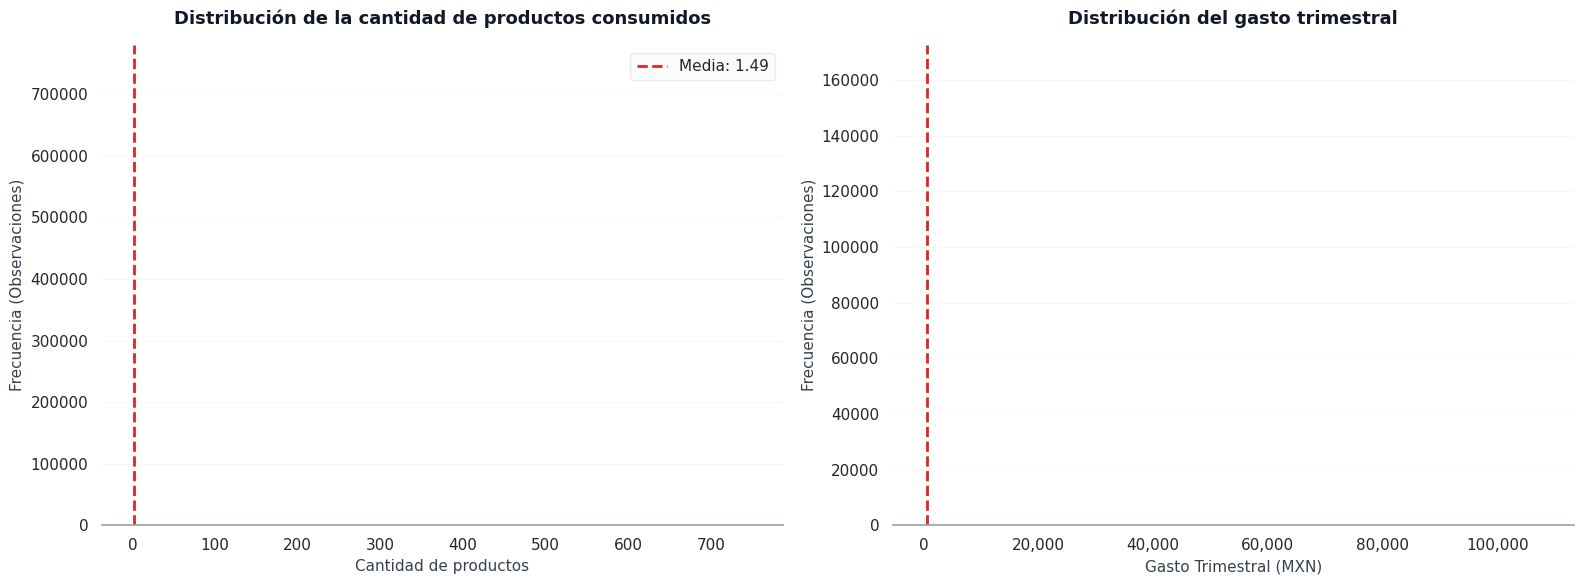

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuración del estilo global para una estética clara e institucional
plt.style.use("default")  # Restablece los parámetros base de Matplotlib
sns.set_theme(
    style="white",
    rc={
        "figure.facecolor": "#FFFFFF",  # Fondo del lienzo externo
        "axes.facecolor": "#FFFFFF",    # Fondo del área de graficación
        "grid.color": "#F3F4F6",        # Rejillas sutiles en gris claro
        "axes.edgecolor": "#9CA3AF"     # Color de los ejes perimetrales
    }
)

# 2. Inicialización de la figura (1 fila y 2 columnas)
plt.figure(figsize=(16, 6))

# --- GRÁFICA 1: CANTIDAD ---
plt.subplot(1, 2, 1)

# Cálculo descriptivo de la media
media_cantidad = df_enigh24_completo_limpio["cantidad"].mean()

# Histograma con tono azul medio y bordes limpios para distinguir densidades
sns.histplot(
    data=df_enigh24_completo_limpio,
    x="cantidad",
    color="#3B82F6",       # Azul institucional
    edgecolor="#FFFFFF",   # Línea de separación blanca entre barras
    linewidth=0.6,
    alpha=0.85
)

# Inserción de la línea vertical para la media (Rojo carmesí normativo)
plt.axvline(
    x=media_cantidad,
    color="#DC2626",
    linestyle="--",
    linewidth=2,
    label=f"Media: {media_cantidad:.2f}"
)

# Formalización de etiquetas y títulos
plt.title("Distribución de la cantidad de productos consumidos", fontsize=13, pad=15, fontweight="bold", color="#111827")
plt.xlabel("Cantidad de productos", fontsize=11, color="#374151")
plt.ylabel("Frecuencia (Observaciones)", fontsize=11, color="#374151")

# Guías visuales y leyendas institucionales
plt.grid(axis="y", linestyle="-", linewidth=0.5)
plt.legend(frameon=True, facecolor="#F9FAFB", edgecolor="#E5E7EB")
sns.despine(left=True, bottom=False) # Remoción de bordes innecesarios para limpieza visual

# --- GRÁFICA 2: GASTO TRIMESTRAL ---
plt.subplot(1, 2, 2)

# Cálculo descriptivo de la media
media_gasto = df_enigh24_completo_limpio["gasto_tri"].mean()

# Renderizado del histograma
sns.histplot(
    data=df_enigh24_completo_limpio,
    x="gasto_tri",
    color="#1E3A8A",       # Azul profundo
    edgecolor="#FFFFFF",
    linewidth=0.6,
    alpha=0.85
)

# Inserción de la línea vertical para la media
plt.axvline(
    x=media_gasto,
    color="#DC2626",
    linestyle="--",
    linewidth=2,
    label=f"Media: ${media_gasto:,.2f}"
)

# Formalización de etiquetas, títulos y formato de datos monetarios
plt.title("Distribución del gasto trimestral", fontsize=13, pad=15, fontweight="bold", color="#111827")
plt.xlabel("Gasto Trimestral (MXN)", fontsize=11, color="#374151")
plt.ylabel("Frecuencia (Observaciones)", fontsize=11, color="#374151")

# Formatear el eje X con separadores de miles para la escala monetaria de la ENIGH
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Guías visuales y leyendas
plt.grid(axis="y", linestyle="-", linewidth=0.5)
sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

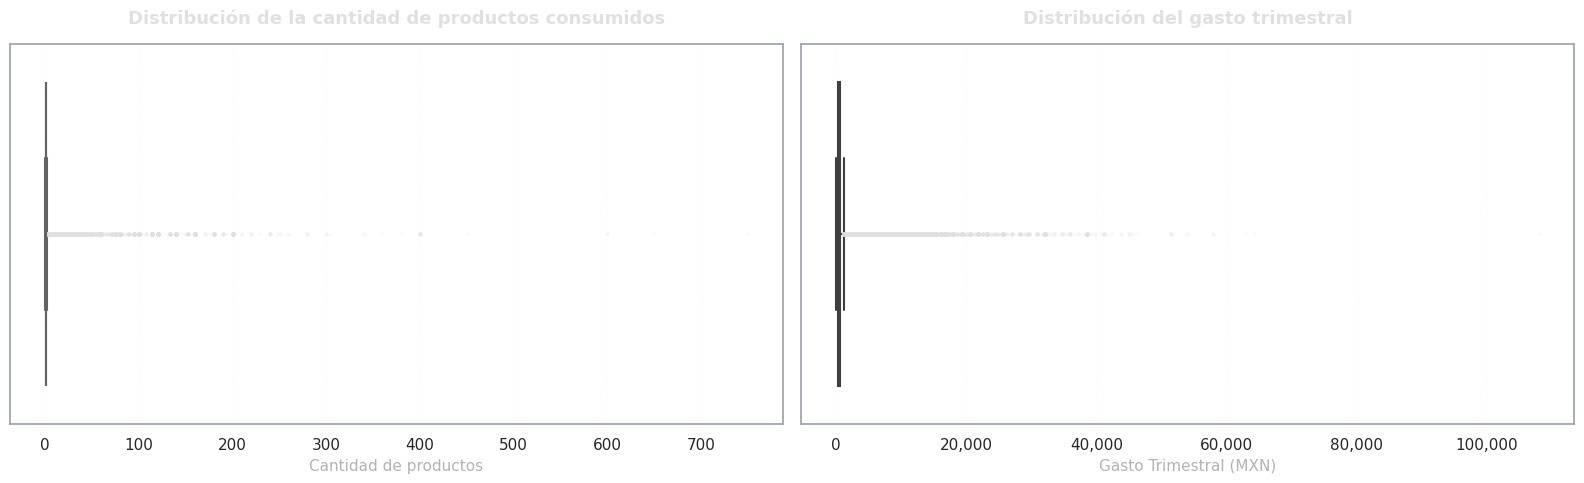

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


# Inicialización del lienzo
plt.figure(figsize=(16, 5))

# Configuración uniforme para los valores atípicos (outliers)
propiedades_outliers = {
    "marker": "o",
    "markersize": 3,
    "markerfacecolor": "#E0E0E0",
    "markeredgecolor": "none",
    "alpha": 0.15 # Opacidad reducida para manejar la alta densidad de la ENIGH
}

# --- GRÁFICA 1: CANTIDAD ---
plt.subplot(1, 2, 1)

sns.boxplot(
    data=df_enigh24_completo_limpio,
    x="cantidad",
    color=plt.cm.magma(0.65),
    linewidth=1.5,
    fliersize=3,
    flierprops=propiedades_outliers
)

# Optimización de ejes y etiquetas
plt.title("Distribución de la cantidad de productos consumidos", fontsize=13, pad=15, fontweight="bold", color="#E0E0E0")
plt.xlabel("Cantidad de productos", fontsize=11, color="#B3B3B3")
plt.grid(axis="x", linestyle=":", alpha=0.3) # Rejilla vertical para identificar valores exactos

# --- GRÁFICA 2: GASTO TRIMESTRAL ---
plt.subplot(1, 2, 2)

sns.boxplot(
    data=df_enigh24_completo_limpio,
    x="gasto_tri",
    color=plt.cm.magma(0.45),     # Tono contrastante de la misma paleta
    linewidth=1.5,
    fliersize=3,
    flierprops=propiedades_outliers
)

# Optimización de ejes, etiquetas y formato monetario
plt.title("Distribución del gasto trimestral", fontsize=13, pad=15, fontweight="bold", color="#E0E0E0")
plt.xlabel("Gasto Trimestral (MXN)", fontsize=11, color="#B3B3B3")
plt.grid(axis="x", linestyle=":", alpha=0.3)

# Formatear el eje X con separadores de miles para facilitar la lectura de montos financieros
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# 3. Ajuste de márgenes y renderizado
plt.tight_layout()
plt.show()

Encontramos valores extremos en ambas variables numéricas, por lo que procedemos a discriminar estos valores mediante el método de cuantiles.

**Explicación:** los gastos extremos representan gastos de lujo o compras enormes, algo que sólo una proporción muy pequeña de la población puede permitirse. En cambio, nos interesa el grueso poblacional, por lo que delimitamos nuestra variable.

In [ ]:
#Calculamos nuestras medidas centrales
registro_iniciales = len(df_enigh24_completo_limpio)
print(f"Cantidad de registros iniciales: {registro_iniciales}")

df_enigh24_completo_iqr = df_enigh24_completo_limpio.copy()

for col in col_num_float:
  q1, q2, q3 = df_enigh24_completo_iqr[col].quantile([0.25, 0.50,0.75])
  iqr = q3 - q1
  lim_superior = q3 + 1.5 * iqr
  lim_inferior = q1 - 1.5 * iqr
  #Filtramos los valores atípicos
  df_enigh24_completo_iqr = df_enigh24_completo_iqr[
      (df_enigh24_completo_iqr[col] >= lim_inferior) &
      (df_enigh24_completo_iqr[col] <= lim_superior)
  ]


print(f"Cantidad de registros después de eliminar los valores atípicos: {len(df_enigh24_completo_iqr)}")

prop_registros_eliminados = (registro_iniciales - len(df_enigh24_completo_iqr)) / registro_iniciales * 100
print(f"Porcentaje de registros eliminados: {prop_registros_eliminados:.2f}%")

Cantidad de registros iniciales: 2249525
Cantidad de registros después de eliminar los valores atípicos: 1661888
Porcentaje de registros eliminados: 26.12%


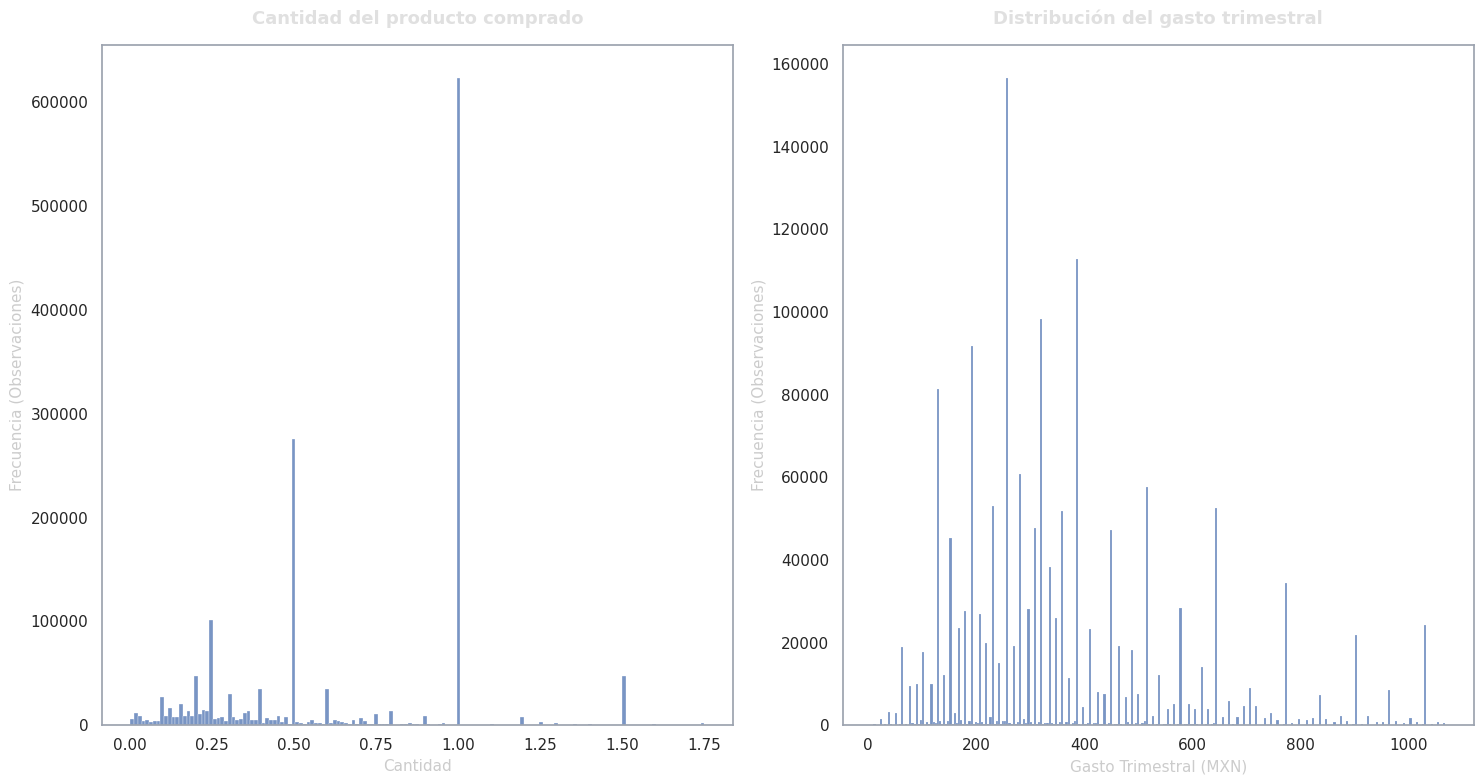

In [ ]:
#Exploramos nuestra base sin outliers
#Histograma de distribución de costos y gastos
plt.figure(figsize= (15,8))
plt.subplot(1,2,1)
sns.histplot(x = df_enigh24_completo_iqr["cantidad"])
# Formalización de etiquetas y títulos con formato monetario en la leyenda
plt.title("Cantidad del producto comprado", fontsize=13, pad=15, fontweight="bold", color="#E0E0E0")
plt.xlabel("Cantidad", fontsize=11, color="#CCCCCC")
plt.ylabel("Frecuencia (Observaciones)", fontsize=11, color="#CCCCCC")
plt.grid(axis="y", linestyle=":", alpha=0.2, color="white")

plt.subplot(1,2,2)
sns.histplot(x = df_enigh24_completo_iqr["gasto_tri"])
# Formalización de etiquetas y títulos con formato monetario en la leyenda
plt.title("Distribución del gasto trimestral", fontsize=13, pad=15, fontweight="bold", color="#E0E0E0")
plt.xlabel("Gasto Trimestral (MXN)", fontsize=11, color="#CCCCCC")
plt.ylabel("Frecuencia (Observaciones)", fontsize=11, color="#CCCCCC")
plt.grid(axis="y", linestyle=":", alpha=0.2, color="white")

# 3. Ajuste de márgenes para evitar solapamiento de textos
plt.tight_layout()
plt.show()

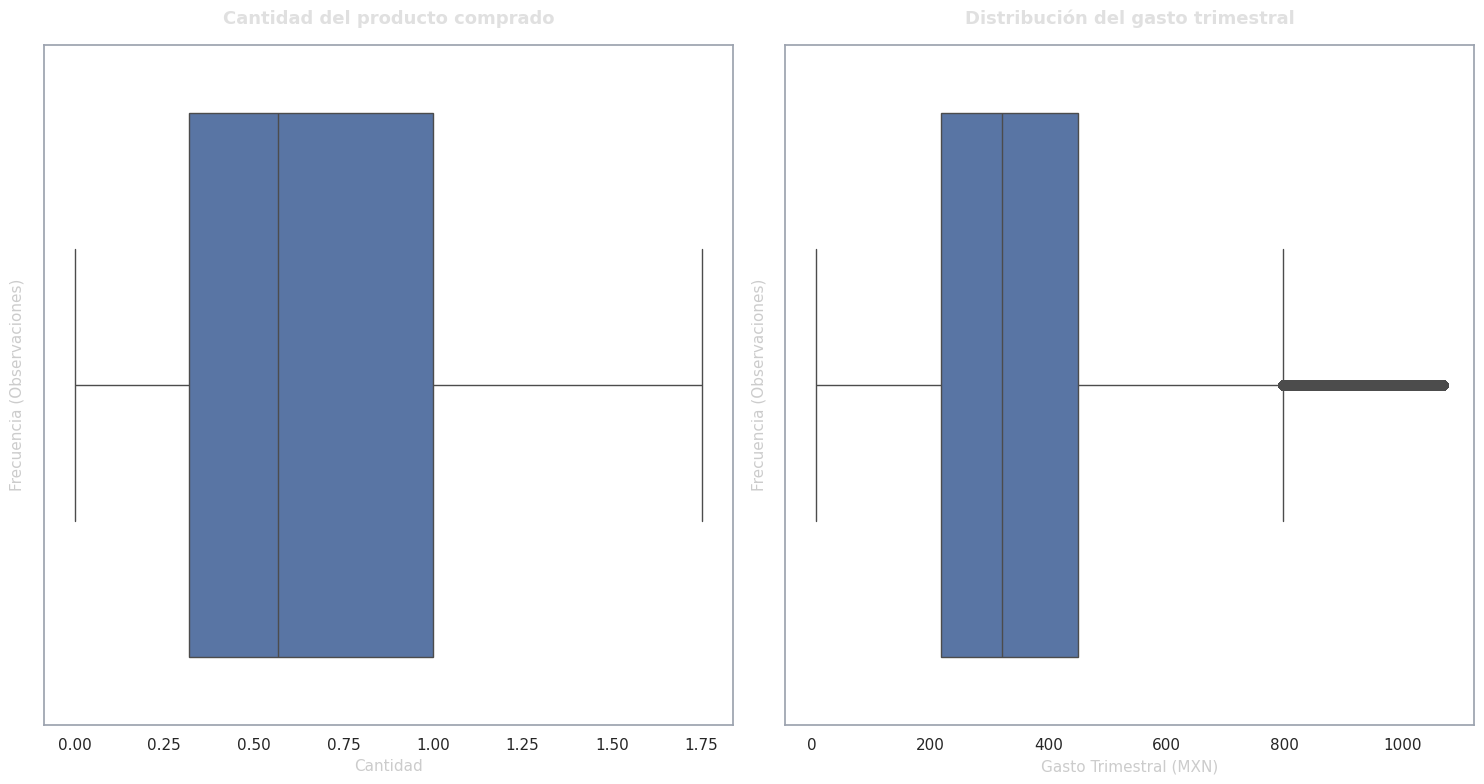

In [ ]:
#Exploramos nuestra base sin outliers
#Histograma de distribución de costos y gastos
plt.figure(figsize= (15,8))
plt.subplot(1,2,1)
sns.boxplot(x = df_enigh24_completo_iqr["cantidad"])
# Formalización de etiquetas y títulos con formato monetario en la leyenda
plt.title("Cantidad del producto comprado", fontsize=13, pad=15, fontweight="bold", color="#E0E0E0")
plt.xlabel("Cantidad", fontsize=11, color="#CCCCCC")
plt.ylabel("Frecuencia (Observaciones)", fontsize=11, color="#CCCCCC")
plt.grid(axis="y", linestyle=":", alpha=0.2, color="white")

plt.subplot(1,2,2)
sns.boxplot(x = df_enigh24_completo_iqr["gasto_tri"])
# Formalización de etiquetas y títulos con formato monetario en la leyenda
plt.title("Distribución del gasto trimestral", fontsize=13, pad=15, fontweight="bold", color="#E0E0E0")
plt.xlabel("Gasto Trimestral (MXN)", fontsize=11, color="#CCCCCC")
plt.ylabel("Frecuencia (Observaciones)", fontsize=11, color="#CCCCCC")
plt.grid(axis="y", linestyle=":", alpha=0.2, color="white")

# 3. Ajuste de márgenes para evitar solapamiento de textos
plt.tight_layout()
plt.show()

**Aclaración:** estas gráficas representan mejor nuestro objetivo de proyecto: el gasto regular mexicano. Prescindiendo de gastos extremos y cantidades atípicas, podemos descartar la compra de productos de lujo o de alto costo que sólo un sector específico de la población puede obtener. Además, limitando la cantidad de consumo, sorteamos aquellos hogares que compran para la venta o para el almacenamiento extendido.

Exploramos si existe correlación entre nuestras variables numéricas.

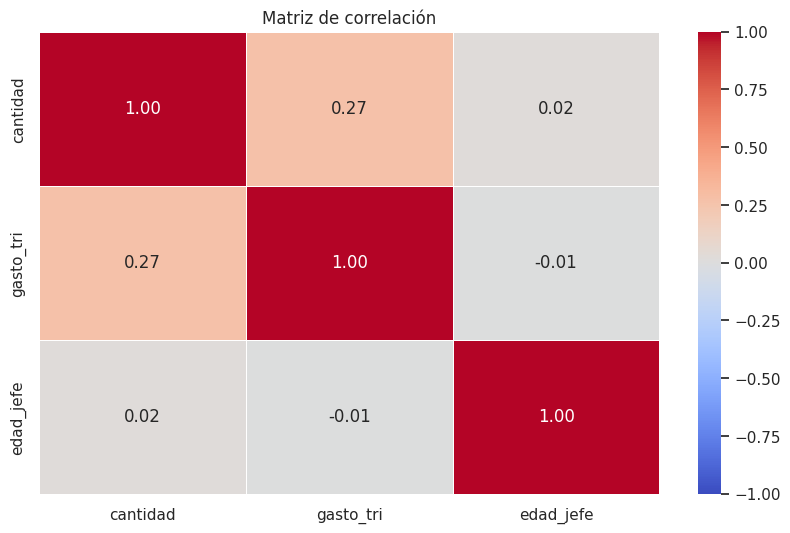

In [ ]:
#Identificamos si existe alguna correlación entre nuestras variables
col_numericas = ["cantidad", "gasto_tri", "edad_jefe"]
correlacion = df_enigh24_completo_iqr[col_numericas].corr()
plt.figure(figsize = (10,6))
sns.heatmap(correlacion, annot = True, cmap = "coolwarm", fmt = ".2f", linewidths= 0.5, vmin = -1, vmax=1)
plt.title("Matriz de correlación")
plt.show()

Como resultado, el coeficiente de correlación es despreciable, ya que un 0.27 (siendo el más alto) representa una relación débilmente establecida entre gasto trimestral y cantidad. La relación es aún más débil para el caso de la edad con el gasto (-0.01).

Para estas correlaciones se omitieron las varibles folioviv, foliviv y factor. Las primeras dos por ser identificadores de los datos y el último por ser un ponderador.

## ¿En qué, cómo y quién gasta en el hogar?
A continuación se presentan unas gráficas que ayudan a responder las preguntas sobre qué es lo que más se compra en el hogar, el formato de pago que utilizan, las cantidades de la compra y el perfil del consumidor.

###¿Qué se compra?
A continuación se presenta una radiografía general de los 20 productos más comprados.

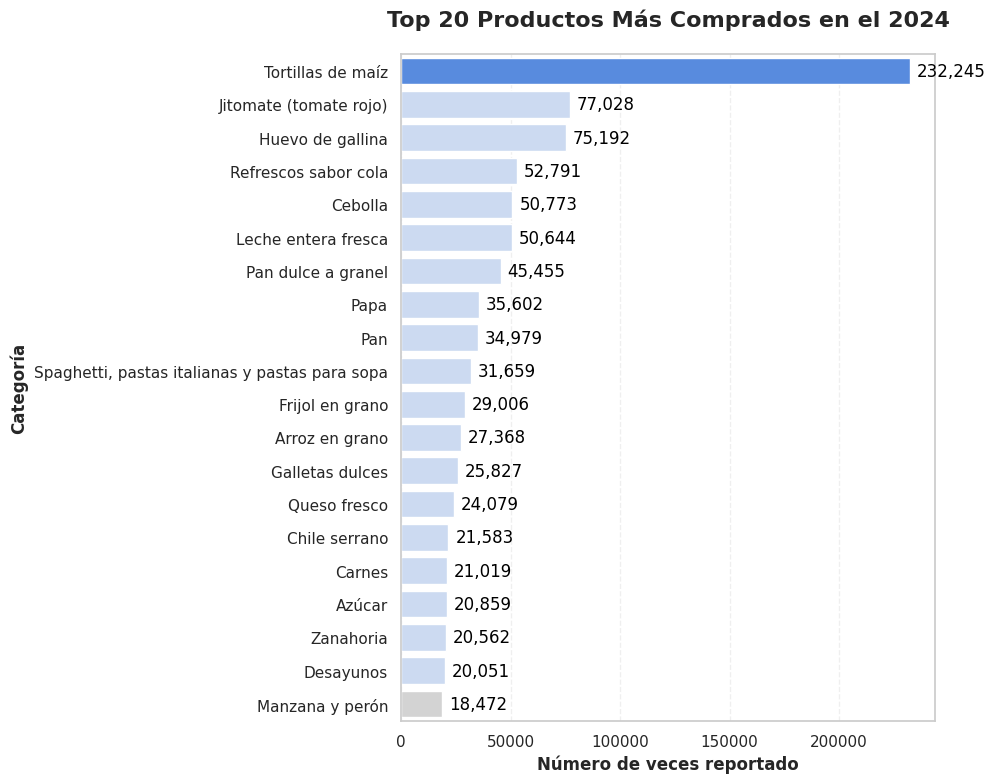

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#Reemplazamos valores de las categorías para ajusar la gráfica
nombre_viejo = 'Chorizo de pollo, jamón de pollo, pavo y otras aves; nuggets de pollo y otras aves, salchicha, mortadela, tocino de pollo, pavo y otras aves, etcétera.'
nombre_nuevo = 'Carnes'

df_enigh24_completo_iqr['categoría'] = df_enigh24_completo_iqr['categoría'].replace(nombre_viejo, nombre_nuevo)

#Tomamos el top 20 de productos
top_20prod = df_enigh24_completo_iqr['categoría'].value_counts().head(20)

# Preparamos datos para la gráfica
values = top_20prod.values
order = top_20prod.index

# Colores: máximo azul fuerte, mínimo gris, resto azul claro
colors = ['#4285F4' if v == values.max() else '#D3D3D3' if v == values.min() else '#C6D9F7' for v in values]

#Graficamos las barras horizontales
plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")
ax = sns.barplot(x=values, y=order, palette=colors, hue=order, legend=False)

# Anota valores en cada barra
for p in ax.patches:
    ax.annotate(f"{int(p.get_width()):,}", # con comas
                (p.get_width(), p.get_y() + p.get_height() / 2),
                ha="left", va="center", fontsize=12, color="black",
                xytext=(5,0), textcoords="offset points")

# Títulos y formato
plt.title("Top 20 Productos Más Comprados en el 2024", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Número de veces reportado", fontsize=12, fontweight="bold")
plt.ylabel("Categoría", fontsize=12, fontweight="bold")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_134917/2349913516.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gasto_prom = df_top20.groupby('categoría').apply(


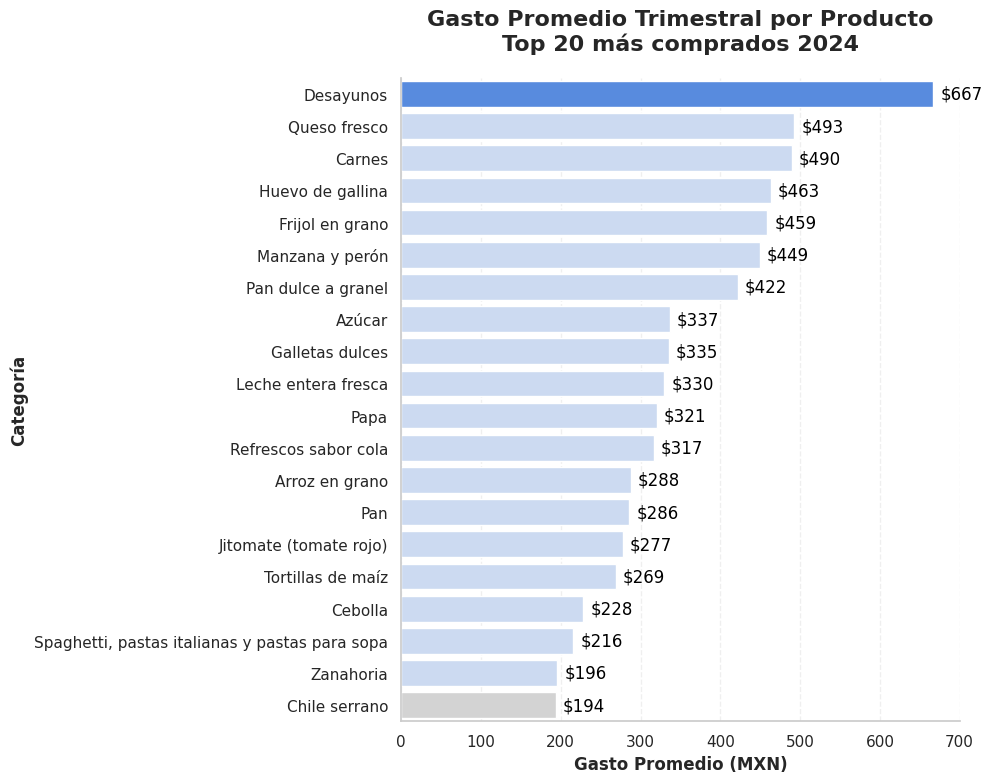

In [ ]:

# Filtramos solo las 20 categorías
top20_cats = top_20prod.index.tolist()
df_top20 = df_enigh24_completo_iqr[df_enigh24_completo_iqr['categoría'].isin(top20_cats)].copy()

# 2. Gasto promedio ponderado por factor - ordenado por gasto
gasto_prom = df_top20.groupby('categoría').apply(
    lambda x: (x['gasto_tri'] * x['factor']).sum() / x['factor'].sum() #Usamos el ponderador del INEGI para obtener los datos correctos
).sort_values(ascending=False)

# Prepara datos para la gráfica
values = gasto_prom.values
order = gasto_prom.index

# Colores: máximo azul fuerte, mínimo gris, resto azul claro
colors = ['#4285F4' if v == values.max() else '#D3D3D3' if v == values.min() else '#C6D9F7' for v in values]

# Graficamos
plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")
ax = sns.barplot(x=values, y=order, palette=colors, hue=order, legend=False)

# Anotamos valores en cada barra con $
for p in ax.patches:
    ax.annotate(f"${p.get_width():,.0f}",
                (p.get_width(), p.get_y() + p.get_height() / 2),
                ha="left", va="center", fontsize=12, color="black",
                xytext=(5,0), textcoords="offset points")

# Títulos y formato
plt.title("Gasto Promedio Trimestral por Producto\nTop 20 más comprados 2024",
          fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Gasto Promedio (MXN)", fontsize=12, fontweight="bold")
plt.ylabel("Categoría", fontsize=12, fontweight="bold")
plt.grid(axis="x", linestyle="--", alpha=0.3)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

## ¿Cómo gastan?
Un diagrama de pie nos ayuda a saber la proporción del método de pago para comprar los productos.

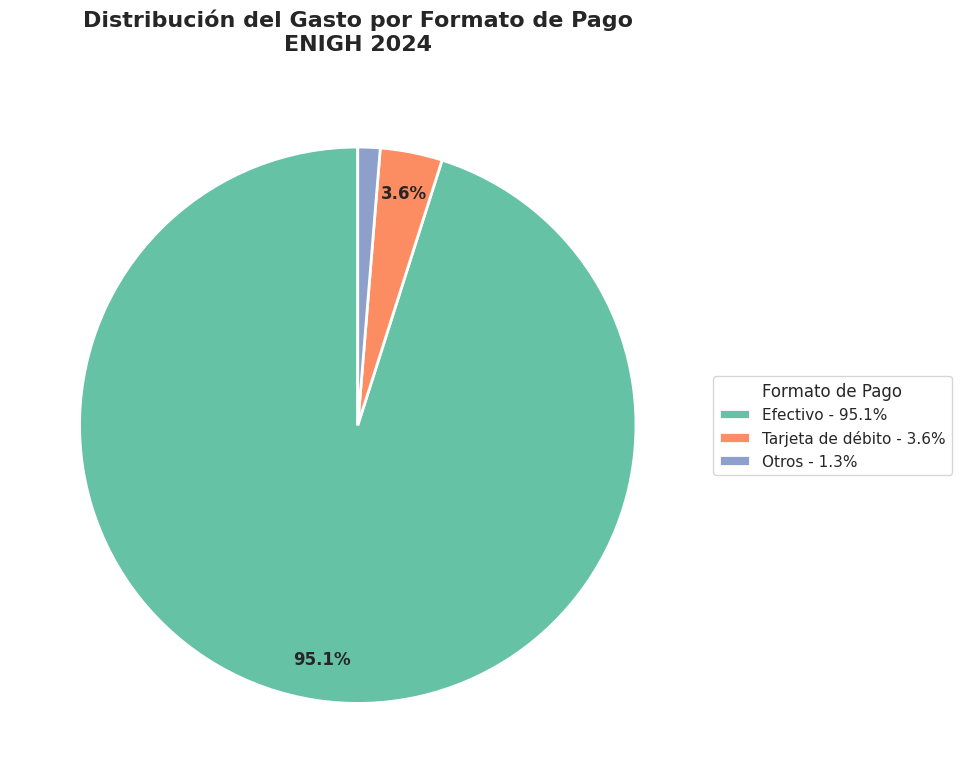

In [ ]:
# Gasto total por forma_pago - ponderado con factor
pago_total = df_enigh24_completo_iqr.groupby('forma_pago', observed=True).apply(
    lambda x: (x['gasto_tri'] * x['factor']).sum(), include_groups=False
).sort_values(ascending=False)

# Porcentajes
porcentajes = 100 * pago_total / pago_total.sum()

#Agrupmos categorías pequeñas
umbral = 2
mask_otros = porcentajes < umbral

# Cremos una nueva serie para graficar
if mask_otros.any():
    # Sumamos los porcentajes para "otros"
    otros_porcentaje = porcentajes[mask_otros].sum()
    # Llenamos las categorías que están debajo del umbral
    porcentajes_final = porcentajes[~mask_otros].copy()
    porcentajes_final.loc['Otros'] = otros_porcentaje
    porcentajes_final = porcentajes_final.sort_values(ascending=False)
else:
    porcentajes_final = porcentajes.sort_values(ascending=False)

# Usamos los porcentajes finales para el gráfica
plt.figure(figsize=(10, 8))
colors = plt.cm.Set2.colors

wedges, texts, autotexts = plt.pie(
    porcentajes_final.values,
    labels=None,  # <- Quita labels de adentro
    autopct=lambda pct: f'{pct:.1f}%' if pct > umbral else '',  # <- Solo muestra % si >umbral
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    pctdistance=0.85,  # % más cerca del centro
    textprops={'fontsize': 12, 'weight': 'bold'}
)

# Leyenda afuera con % incluidos
leyenda_labels = [f'{label} - {val:.1f}%' for label, val in zip(porcentajes_final.index, porcentajes_final.values)]
plt.legend(
    wedges,
    leyenda_labels,
    title="Formato de Pago",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=11
)

plt.title('Distribución del Gasto por Formato de Pago\nENIGH 2024',
          fontsize=16, fontweight="bold", pad=20)

plt.tight_layout()
plt.show()


## ¿Quiénes gastan?

Las siguientes gráficas nos ayudarán a entender algunas rasgos generales de la población (jefes de familias) que realizan el gasto en el hogar.

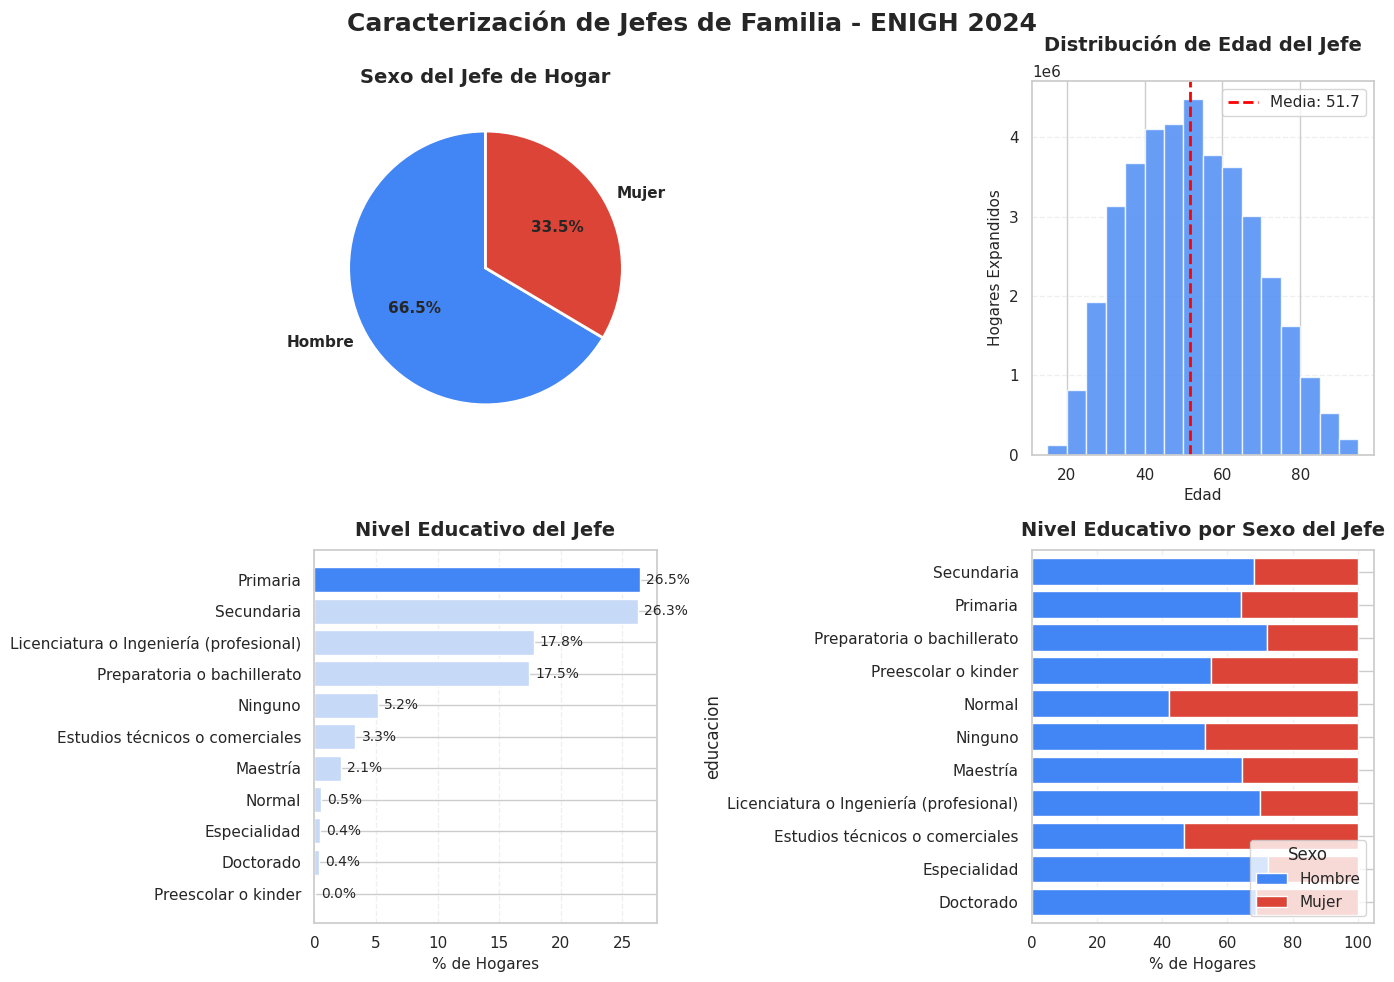

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Agrupamos a nivel hogar y usamos un renglón por jefe
df_hogares = df_enigh24_completo_iqr.drop_duplicates(subset=['folioviv', 'foliohog']).copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Caracterización de Jefes de Familia - ENIGH 2024', fontsize=18, fontweight='bold', y=0.98)

# Definimos el sexo del jefe
sexo_pct = df_hogares.groupby('sexo_jefe', observed=True)['factor'].sum()
sexo_pct = 100 * sexo_pct / sexo_pct.sum()
wedges, texts, autotexts = axes[0,0].pie(
    sexo_pct.values, labels=sexo_pct.index, autopct='%1.1f%%',
    startangle=90, colors=['#4285F4', '#DB4437'],
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 11, 'weight': 'bold'}
)
axes[0,0].set_title('Sexo del Jefe de Hogar', fontsize=14, fontweight='bold', pad=10)

# Edad del jefe
bins_edad = range(15, 96, 5)
axes[0,1].hist(
    df_hogares['edad_jefe'], weights=df_hogares['factor'], bins=bins_edad,
    color='#4285F4', edgecolor='white', alpha=0.8
)
axes[0,1].set_title('Distribución de Edad del Jefe', fontsize=14, fontweight='bold', pad=10)
axes[0,1].set_xlabel('Edad', fontsize=11)
axes[0,1].set_ylabel('Hogares Expandidos', fontsize=11)
axes[0,1].grid(axis="y", linestyle="--", alpha=0.3)
media_edad = (df_hogares['edad_jefe'] * df_hogares['factor']).sum() / df_hogares['factor'].sum()
axes[0,1].axvline(media_edad, color='red', linestyle='--', linewidth=2, label=f'Media: {media_edad:.1f}')
axes[0,1].legend()

# Nivel educativo
edu_pct = df_hogares.groupby('educacion', observed=True)['factor'].sum()
edu_pct = 100 * edu_pct / edu_pct.sum()
edu_pct = edu_pct.sort_values()
colors_edu = ['#D3D3D3' if v == edu_pct.min() else '#4285F4' if v == edu_pct.max() else '#C6D9F7' for v in edu_pct.values]
axes[1,0].barh(edu_pct.index, edu_pct.values, color=colors_edu)
axes[1,0].set_title('Nivel Educativo del Jefe', fontsize=14, fontweight='bold', pad=10)
axes[1,0].set_xlabel('% de Hogares', fontsize=11)
axes[1,0].grid(axis="x", linestyle="--", alpha=0.3)
for i, v in enumerate(edu_pct.values):
    axes[1,0].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10)

# Educación por sexo
tabla_edu_sexo = pd.crosstab(
    index=df_hogares['educacion'],
    columns=df_hogares['sexo_jefe'],
    values=df_hogares['factor'],
    aggfunc='sum',
    normalize='index'
) * 100

tabla_edu_sexo.plot(
    kind='barh',
    stacked=True,
    ax=axes[1,1],
    color=['#4285F4', '#DB4437'],
    width=0.8
)
axes[1,1].set_title('Nivel Educativo por Sexo del Jefe', fontsize=14, fontweight='bold', pad=10)
axes[1,1].set_xlabel('% de Hogares', fontsize=11)
axes[1,1].legend(title='Sexo', loc='lower right')
axes[1,1].grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

## **Conclusión**
Como corolario, presentamos los hallazgos más significativos.

Los productos más vendidos son las tortillas de maíz, aunque el producto en el que más se gasta trimestralmente es en desayunos, siendo el formato de pago en efectivo el más utilizado.

El perfil de los jefes de familia, encargados, en general, de hacer los gastos, son en mayor porcentaje hombres (66.5%), con una media de edad de 51.7 años de edad, cuyos grados de estudios están entre primaria y secundaria.

Lo anterior revela un gasto enfocado en la dieta diaria, con un gasto particular en las comidas preparadas, con una desproporción inclinada hacia el sexo masculino con edad avanzada con estudios aprobados hasta niveles bajos educativos.

Dependiendo del enfoque empresarial, esto podría ser un buen principio de segmentación del consumidor o un sectorización para polítcas públicas.